In [1]:
# ===========================================
# Libraries
# ===========================================

import numpy as np
import pandas as pd
from scipy.integrate import trapezoid, cumulative_trapezoid
import emcee
import time
from multiprocessing import Pool
from getdist import MCSamples, plots
import matplotlib.pyplot as plt

In [2]:
# ========================================================
# Loading DESI BAO DR2 data
# ========================================================

bao_dat_path = "/home/brunowesley/projetos/MCMC-cosmo/Data/BAO/desi_gaussian_bao_ALL_GCcomb_mean.txt"
bao_cov_path = "/home/brunowesley/projetos/MCMC-cosmo/Data/BAO/desi_gaussian_bao_ALL_GCcomb_cov.txt"

df_bao   = pd.read_csv(bao_dat_path, sep=r"\s+", comment="#", names=["z", "value", "quantity"])

z_bao    = df_bao["z"].values
d_obs    = df_bao["value"].values
q_bao    = df_bao["quantity"].str.lower().values

cov_bao  = np.loadtxt(bao_cov_path)
Cinv_bao = np.linalg.inv(cov_bao)


# ====================================================
# Loading FRB data
# ====================================================

frb_dat_path = "/home/brunowesley/projetos/MCMC-cosmo/Data/FRB/frb_catalog.txt"
df_frb       = pd.read_csv(frb_dat_path, sep=r"\t", engine="python")
df_frb       = df_frb.sort_values(by="Redshift", ascending=True).reset_index(drop=True)

z_frb        = df_frb["Redshift"].to_numpy(float)
DM_obs       = df_frb["DM_obs"].to_numpy(float)
DM_MW        = df_frb["DM_MW_ISM_(NE2001)"].to_numpy(float)
DM_MW_total  = DM_MW + 50.0          # MW ISM + halo contribution [pc/cm^3]
DM_ext_obs   = DM_obs - DM_MW_total  # extragalactic DM [pc/cm^3]

In [3]:
# ====================================================
# Fiducial / Priors
# ====================================================

# Uniform priors
H0_min,       H0_max       = 50.0,  90.0
Om0_min,      Om0_max      = 0.1,   0.6
sig_host_min, sig_host_max = 0.2,   2.0
e_mu_min,     e_mu_max     = 20.0,  200.0

# Gaussian prior on baryon density Ob
mu_Ob, sigma_Ob = 0.0495, 0.0025

# Physical constants
c_kms = 299792.458         # speed of light [km/s]
c_si  = 2.99792458e8       # speed of light [m/s]
G_si  = 6.67430e-11        # gravitational constant [m^3 kg^-1 s^-2]
mp_si = 1.67262192369e-27  # proton mass [kg]

# Unit conversions
km_to_pc  = 1.0 / (3.0857e13)
m2_to_cm2 = 1e4
Mpc_to_cm = 3.0857e24

# Astrophysical/cosmological parameters
f_IGM = 0.83
chi_e = 0.875
Neff  = 3.046


# ====================================================
# Redshift / scale-factor grids
# ====================================================

zi, zf = 0.0, 2.5
N_grid = 2000
z_grid = np.linspace(zi, zf, N_grid)
dz     = np.diff(z_grid)

In [4]:
# ========================================================
# Hubble functions
# ========================================================

def E_LCDM(z, Om0):
    Om = Om0 * (1 + z)**3
    Ol0 = 1 - Om0
    return np.sqrt(Om + Ol0)

def H_LCDM(z, H0, Om0):
    return H0 * E_LCDM(z, Om0)

In [ ]:
# ========================================================
# BAO functions
# ========================================================

# Comoving distance
def comoving_dist(z, H0, Om0):
    E_vals = E_LCDM(z_grid, Om0)
    integrand = 1.0 / E_vals
    integral = np.empty_like(z_grid)
    integral[0] = 0.0
    integral[1:] = np.cumsum(0.5 * (integrand[1:] + integrand[:-1]) * dz)
    I_z = np.interp(z, z_grid, integral)
    return (c_kms / H0) * I_z


# Theoretical BAO vector
def d_LCDM(z_arr, q_arr, H0, Om0, Ob):
    h2 = (H0 / 100.0)**2
    Obh2 = Ob * h2
    Omh2 = Om0 * h2
    rd = 147.05 * ((Obh2/0.02236)**-0.13) \
                  * ((Omh2/0.1432)**-0.23) \
                  * ((Neff/3.04)**-0.1)
    dC = comoving_dist(z_arr, H0, Om0)
    H_z = H_LCDM(z_arr, H0, Om0)
    dm = dC / rd
    dh = (c_kms / H_z) / rd
    dv = (z_arr * dm**2 * dh)**(1/3)
    d_bao = np.empty_like(z_arr)
    mask_dv = np.array(["dv" in q for q in q_arr])
    mask_dm = np.array(["dm" in q for q in q_arr])
    mask_dh = np.array(["dh" in q for q in q_arr])
    d_bao[mask_dv] = dv[mask_dv]
    d_bao[mask_dm] = dm[mask_dm]
    d_bao[mask_dh] = dh[mask_dh]
    return d_bao


# ========================================================
# Quick test
# ========================================================

print("d_LCDM(z_bao) =",
       d_LCDM(z_bao, q_bao, 70, 0.3, 0.0495))


=== BAO vector test ===
d_LCDM(z_bao) = [ 7.9215958  13.28662514 22.49921066 17.44876055 20.01583222 21.71608081
 17.48233948 27.78279076 14.03859215 29.97363722 12.86746955  8.63018089
 38.88468689]


In [ ]:
# ====================================================
# Theoretical IGM dispersion measure [pc/cm^3]
# ====================================================

def DM_IGM_LCDM(z, H0, Om0, Ob):
    prefactor = 3.0 * c_si * f_IGM * chi_e / (8.0 * np.pi * G_si * mp_si)
    H_grid    = H_LCDM(z_grid, H0, Om0)
    integrand = (1 + z_grid) / H_grid
    I_grid    = cumulative_trapezoid(integrand, z_grid, initial=0.0)
    I_z       = np.interp(z, z_grid, I_grid)
    DM_IGM_z    = prefactor * Ob * H0**2 * I_z                      # Before units conversion
    DM_IGM_corr = DM_IGM_z * (km_to_pc / (m2_to_cm2 * Mpc_to_cm))   # Physical units (pc cm^-3)
    return DM_IGM_corr


# ====================================================
# Quick test
# ====================================================

print("DM_IGM_LCDM(z_frb) =",
       DM_IGM_LCDM(z_frb, 70, 0.3, 0.0495))


=== FRB test ===
DM_IGM_LCDM(z_frb) = [   7.21789704   16.17960481   20.19502221   25.44874419   25.82746447
   36.61189171   36.88132956   40.22844688   51.84362866   55.13063809
   55.48068882   56.79381448   60.38758746   61.54604726   61.70410808
   62.93364932   67.68330375   77.48187561   80.22672273   81.46755396
   85.10562968   91.33117324   93.78185509   93.91562494   95.78894031
   99.27223076  102.74302537  103.29814514  103.38768058  106.79296383
  106.91849675  110.56251937  111.01171388  113.07895822  113.70842833
  121.27561091  124.07416648  128.5041566   138.02319787  138.11402384
  139.23961745  141.56773272  156.52424721  162.65772599  169.90661857
  170.64162644  170.76111118  181.50467392  186.67338932  188.0593213
  190.83301133  204.27227361  208.91899526  211.24470019  214.03761544
  215.80474502  216.64628604  217.48520665  219.16358321  224.29687853
  224.48368546  235.52133306  243.49184743  248.56370711  250.53785143
  251.66634102  256.34247492  258.53787

In [ ]:
# ====================================================
# BAO + FRB likelihood
# ====================================================

# Log-prior
def lnprior_bao_frb(theta):
    H0, Om0, Ob, sigma_host, exp_mu = theta
    if not (H0_min       <= H0         <= H0_max):       return -np.inf
    if not (Om0_min      <= Om0        <= Om0_max):      return -np.inf
    if not (0.0          <  Ob         <  Om0):          return -np.inf
    if not (sig_host_min <= sigma_host <= sig_host_max): return -np.inf
    if not (e_mu_min     <= exp_mu     <= e_mu_max):     return -np.inf
    lp_Ob = -0.5 * ((Ob - mu_Ob) / sigma_Ob)**2
    return lp_Ob


# Convolved FRB PDF: IGM (Gaussian) + host galaxy (log-normal)
def P_DM_ext_vectorized(z_frb, DM_ext_obs, DM_IGM_mean, sigma_IGM,
                         sigma_host, exp_mu, npts=300):
    
    mu_host      = np.log(exp_mu)
    upper        = max(DM_ext_obs.max(), 5.0 * exp_mu)
    DM_hosp_grid = np.linspace(1e-2, upper, npts)
    DM_hosp_grid = DM_hosp_grid[None, :]                        # (1, npts)
    DM_ext_array      = DM_ext_obs[:, None]                     # (N, 1)
    DM_IGM_array      = DM_ext_array - DM_hosp_grid / (1 + z_frb[:, None])
    sigma_IGM_array   = sigma_IGM[:, None]
    DM_IGM_mean_array = DM_IGM_mean[:, None]
    
    # IGM PDF (Gaussian)
    P_IGM = (1.0 / (np.sqrt(2 * np.pi) * sigma_IGM_array)) \
            * np.exp(-0.5 * ((DM_IGM_array - DM_IGM_mean_array) / sigma_IGM_array)**2)
    
    # Host galaxy PDF (log-normal)
    DM_hosp_array = DM_hosp_grid
    P_host = (1.0 / (np.sqrt(2 * np.pi) * sigma_host * DM_hosp_array)) \
             * np.exp(-0.5 * ((np.log(DM_hosp_array) - mu_host) / sigma_host)**2)
    
    # Convolution via numerical integration over DM_host
    integrand = P_IGM * P_host                                  # (N, npts)
    P_total   = trapezoid(integrand, x=DM_hosp_grid[0], axis=1)
    return np.maximum(P_total, 1e-100)


# Joint likelihood
def lnlike_bao_frb(theta, z_bao, d_obs, q_bao, Cinv_bao, z_frb, DM_ext_obs):
    H0, Om0, Ob, sigma_host, exp_mu = theta
    
    # --- BAO ---
    d_model = d_LCDM(z_bao, q_bao, H0, Om0, Ob)
    if not np.all(np.isfinite(d_model)):
        return -np.inf
    resid_bao = d_obs - d_model
    lnL_bao   = -0.5 * (resid_bao @ Cinv_bao @ resid_bao)
    
    # --- FRB ---
    DM_IGM_mean = DM_IGM_LCDM(z_frb, H0, Om0, Ob)
    if not np.all(np.isfinite(DM_IGM_mean)):
        return -np.inf
    sigma_IGM = 173.8 * (z_frb**0.4)
    P_total   = P_DM_ext_vectorized(z_frb, DM_ext_obs, DM_IGM_mean,
                                     sigma_IGM, sigma_host, exp_mu)
    lnL_frb   = np.sum(np.log(P_total))
    return lnL_bao + lnL_frb


# Joint posterior
def lnprob_bao_frb(theta, z_bao, d_obs, q_bao, Cinv_bao, z_frb, DM_ext_obs):
    lp = lnprior_bao_frb(theta)
    if not np.isfinite(lp):
        return -np.inf
    return lp + lnlike_bao_frb(theta, z_bao, d_obs, q_bao, Cinv_bao, z_frb, DM_ext_obs)


# ====================================================
# Quick test
# ====================================================

theta_test = [70.0, 0.3, 0.0495, 0.7, 120.0]
print("BAO + FRB log-posterior =",
       lnprob_bao_frb(theta_test, z_bao, d_obs, q_bao, Cinv_bao, z_frb, DM_ext_obs))


=== BAO + FRB posterior test ===
BAO + FRB log-posterior = -655.3713650184839


In [8]:
# ====================================================
# MCMC configuration
# ====================================================

ndim     = 5
nwalkers = 40
nsteps   = 50000

theta0 = np.array([70.0, 0.3, 0.0495, 0.7, 120.0])
scales = np.array([ 2.0, 0.02, 0.001, 0.1,  10.0])

rng = np.random.default_rng(42)
p0  = theta0 + scales * rng.standard_normal((nwalkers, ndim))

for i in range(nwalkers):
    while not np.isfinite(lnprior_bao_frb(p0[i])):
        p0[i] = theta0 + scales * rng.standard_normal(ndim)


# ====================================================
# MCMC run
# ====================================================

print(f"\n=== Running MCMC (BAO + FRB) ===")
t_mcmc = time.time()

with Pool(processes=nwalkers) as pool:
    sampler = emcee.EnsembleSampler(
        nwalkers, ndim, lnprob_bao_frb,
        args=(z_bao, d_obs, q_bao, Cinv_bao, z_frb, DM_ext_obs)
    )
    sampler.run_mcmc(p0, nsteps, progress=True)

print(f"\nMCMC completed in {(time.time() - t_mcmc) / 60:.1f} min")


=== Running MCMC (BAO + FRB) ===


100%|██████████| 50000/50000 [13:28<00:00, 61.85it/s]


MCMC completed in 13.5 min


In [9]:
# ====================================================
# Convergence diagnostics
# ====================================================

print("\n=== Convergence diagnostics ===")

chain        = sampler.get_chain()
nsteps_total = chain.shape[0]

acc_frac = np.mean(sampler.acceptance_fraction)
print(f"Mean acceptance fraction: {acc_frac:.3f}")
if   0.2  <= acc_frac <= 0.5:  acc_status = "IDEAL"
elif 0.15 <= acc_frac <= 0.6:  acc_status = "ACCEPTABLE"
else:                           acc_status = "PROBLEMATIC"
print(f"Acceptance status: {acc_status}")

tau          = sampler.get_autocorr_time(tol=0)
tau_max      = np.max(tau)
length_ratio = nsteps_total / tau_max
print(f"\nMax autocorrelation time τ_max = {tau_max:.2f}")
print(f"Chain length / τ_max           = {length_ratio:.1f}")
length_status = "PASSED" if length_ratio >= 50 else "FAILED"
print(f"Length criterion (>50×τ)       : {length_status}")

nburn     = int(3 * tau_max)
nthin     = max(1, int(tau_max / 2))
n_post    = nsteps_total - nburn
N_eff     = nwalkers * (n_post / tau)
N_eff_min = np.min(N_eff)
print(f"\nBurn-in (3×τ_max)              = {nburn} steps ({100*nburn/nsteps_total:.1f}%)")
print(f"Thin (τ_max/2)                 = {nthin}")
print(f"Minimum N_eff                  = {int(N_eff_min)}")
if   N_eff_min >= 2000: eff_status = "EXCELLENT"
elif N_eff_min >= 1000: eff_status = "VERY GOOD"
elif N_eff_min >= 500:  eff_status = "ACCEPTABLE"
else:                   eff_status = "LOW"
print(f"Sampling quality               : {eff_status}")

if acc_status != "PROBLEMATIC" and length_status == "PASSED" and N_eff_min >= 500:
    print("\nCONVERGENCE STATUS: ✅ PASSED")
else:
    print("\nCONVERGENCE STATUS: ❌ NOT RELIABLE")


=== Convergence diagnostics ===
Mean acceptance fraction: 0.550
Acceptance status: ACCEPTABLE

Max autocorrelation time τ_max = 60.31
Chain length / τ_max           = 829.1
Length criterion (>50×τ)       : PASSED

Burn-in (3×τ_max)              = 180 steps (0.4%)
Thin (τ_max/2)                 = 30
Minimum N_eff                  = 33044
Sampling quality               : EXCELLENT

CONVERGENCE STATUS: ✅ PASSED


In [10]:
# ====================================================
# Chain extraction
# ====================================================

# flat_log     = sampler.get_chain(discard=nburn, thin=nthin, flat=True)      # Apply thin
flat_log     = sampler.get_chain(discard=nburn, flat=True)                    # No thin
flat_samples = flat_log.copy()

fname = "flat_samples_LCDM_bao_frb.npy"
np.save(fname, flat_samples)
print(f"\nFinal independent samples : {len(flat_samples)}")
print(f"Burn-in used              : {nburn} steps")
# print(f"Thin                      : {nthin}")
print(f"Saved to                  : {fname}")


Final independent samples : 1992800
Burn-in used              : 180 steps
Saved to                  : flat_samples_LCDM_bao_frb.npy


Removed no burn in


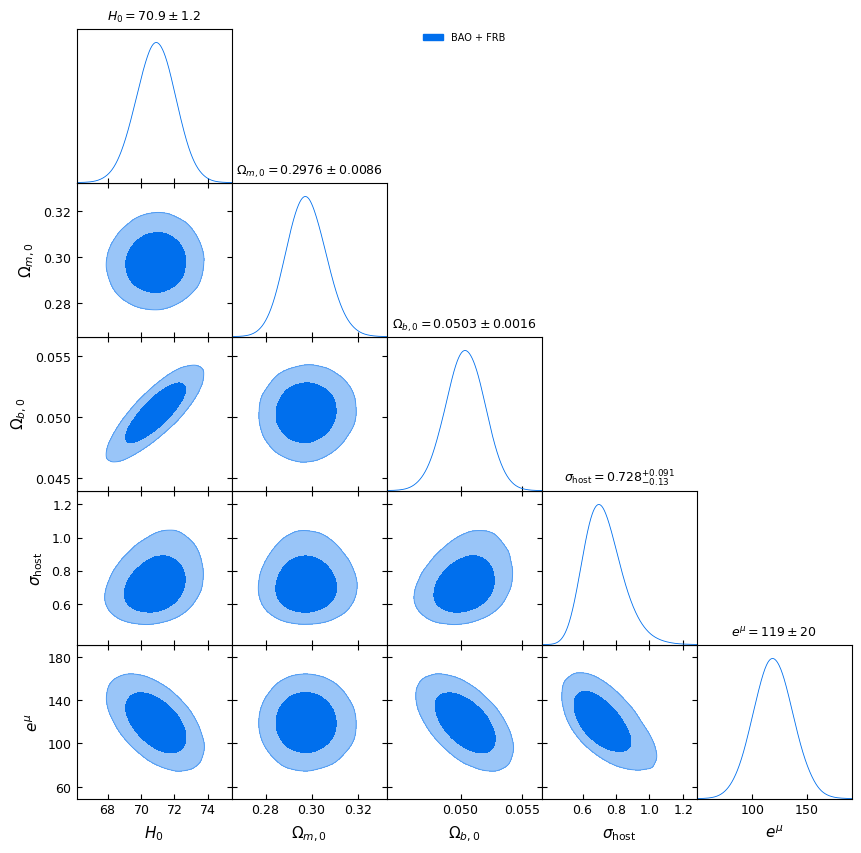

In [11]:
# ====================================================
# Corner plot (GetDist)
# ====================================================

param_names  = ["H0", "Om0", "Ob", "sigma_host", "exp_mu"]
param_labels = [r"H_0", r"\Omega_{m,0}", r"\Omega_{b,0}",
                r"\sigma_{\rm host}", r"e^\mu"]

samples_gd = MCSamples(
    samples=flat_samples,
    names=param_names,
    labels=param_labels
)
samples_gd.updateSettings({
    "smooth_scale_1D": 0.25,
    "smooth_scale_2D": 0.25,
    "fine_bins":       1024,
    "fine_bins_2D":    1024,
})

g = plots.get_subplot_plotter()
g.settings.axes_fontsize       = 12
g.settings.lab_fontsize        = 14
g.settings.legend_fontsize     = 10
g.settings.linewidth_contour   = 1.2
g.settings.num_plot_contours   = 2
g.settings.axis_marker_lw      = 1.0
g.settings.figure_legend_frame = False
g.settings.alpha_filled_add    = 0.3
g.triangle_plot(samples_gd, filled=True,
                legend_labels=["BAO + FRB"],
                title_limit=1)

figname = "Corner_LCDM_bao_frb.png"
plt.savefig(figname, dpi=300, bbox_inches="tight")
plt.show()

In [12]:
# ====================================================
# Marginalized statistics
# ====================================================

marge = samples_gd.getMargeStats()
print("\n" + "="*60)
print(f"{'FINAL INFERENCE RESULTS (LCDM: BAO + FRB)':^60}")
print("="*60)

for name in ["H0", "Om0", "Ob", "sigma_host", "exp_mu"]:
    stats = marge.parWithName(name)
    print(f"\n  {name}:")
    print(f"    Mean ± 1σ : {stats.mean:.4f} ± {stats.err:.4f}")
    print(f"    95% CL    : [{stats.limits[1].lower:.4f}, "
          f"{stats.limits[1].upper:.4f}]")


         FINAL INFERENCE RESULTS (LCDM: BAO + FRB)          

  H0:
    Mean ± 1σ : 70.8765 ± 1.1931
    95% CL    : [68.5062, 73.1853]

  Om0:
    Mean ± 1σ : 0.2976 ± 0.0086
    95% CL    : [0.2812, 0.3149]

  Ob:
    Mean ± 1σ : 0.0503 ± 0.0016
    95% CL    : [0.0471, 0.0535]

  sigma_host:
    Mean ± 1σ : 0.7281 ± 0.1170
    95% CL    : [0.5132, 0.9637]

  exp_mu:
    Mean ± 1σ : 119.2583 ± 18.3444
    95% CL    : [83.4693, 155.4782]


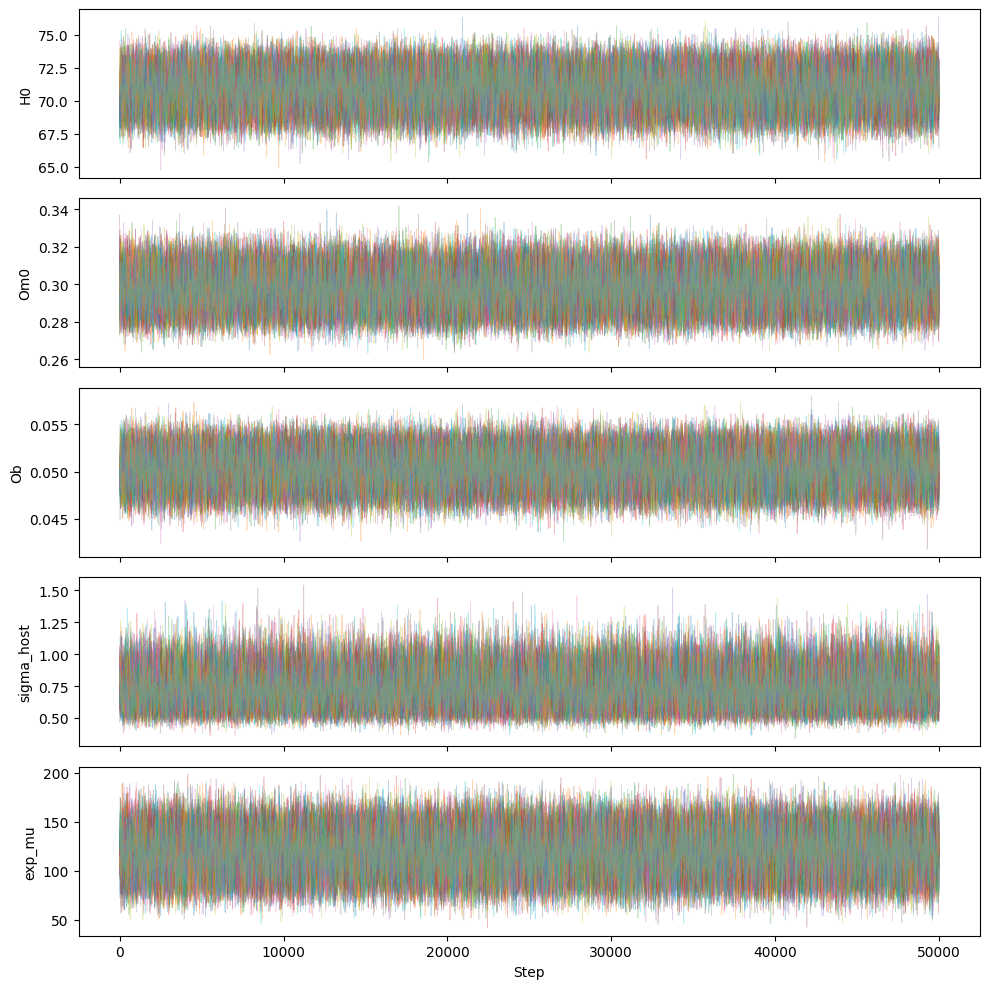

In [13]:
# ====================================================
# Walker chains
# ====================================================

chain_plot = sampler.get_chain().copy()

fig, axes = plt.subplots(5, figsize=(10, 10), sharex=True)
for i, label in enumerate(["H0", "Om0", "Ob", "sigma_host", "exp_mu"]):
    axes[i].plot(chain_plot[:, :, i], alpha=0.3, lw=0.5)
    axes[i].set_ylabel(label)
axes[-1].set_xlabel("Step")
plt.tight_layout()
plt.show()